# Dirichlet Process for Clustering

In this lab we will explore how we can use the Dirichlet Processes (with the stick breaking construction) to cluster customers at a retail store based on their purchase behavior. The data are 2-dimensional and include a feature for the average frequency of visiting the retail store (per year) and the average \$ spending per visit.

We will cluster the customers with 2 methods:


*   Full Bayesian: Dirichlet Process with stick-breaking construction
*   Truncated approximation: Bayesian Gaussian Mixture (Sklearn)  

This will make clear some of the benefits and limitations of non-parametric Bayesian models. In the following cell, we start by defining the stick breaking process and running the full Bayesian model with MCMC. As you will see the code provides you with 2 options: (a) run the DP clustering on both features (as you most probably had planned to do), or, (b) run the DP clustering on one of the dimensions only. The default in the code below is option B, but feel free to change and examine what happens.

In [1]:
# Dirichlet Process Clustering Notebook

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az
from sklearn.mixture import BayesianGaussianMixture
import pandas as pd

df = pd.read_csv("customer_data.csv")
X = np.array(df)

### FULL BAYESIAN MODEL: STICK-BREAKING CONSTRUCTION (PyMC) ###
# Truncation level (K) for approximation
### Using one dimension of the data
def build_model_1d(X1d, K = 10):
      with pm.Model() as model:
        alpha = pm.Gamma("alpha", 2.0, 1.0)
        weights = pm.Dirichlet("weights", a=np.ones(K) * alpha)

        mu = pm.Normal("mu", mu=np.mean(X1d), sigma=20, shape=K)
        sigma = pm.HalfNormal("sigma", sigma=10, shape=K)

        obs = pm.Mixture(
            "obs",
            w=weights,
            comp_dists=pm.Normal.dist(mu=mu, sigma=sigma, shape=K),
            observed=X1d
        )
      return model

### FULL BAYESIAN MODEL: STICK-BREAKING CONSTRUCTION (PyMC) ###
# Truncation level (K) for approximation
### Using both dimensions of the data
def build_model_2d(X2d, K=10):
    D = X2d.shape[1]
    sigma_val = 10.0
    covs = np.array([np.diag([sigma_val**2] * D) for _ in range(K)])

    with pm.Model() as model:
        alpha = pm.Gamma("alpha", 2.0, 1.0)
        weights = pm.Dirichlet("weights", a=np.ones(K) * alpha)

        mu = pm.Normal("mu", mu=np.mean(X2d, axis=0), sigma=20, shape=(K, D))

        mvn = pm.MvNormal.dist(mu=mu, cov=covs, shape=(K, D))

        obs = pm.Mixture("obs", w=weights, comp_dists=mvn, observed=X2d)

    return model



# Choose model (e.g., from user input or flag)
use_2d = False  # or True

X1d = X[:, 0]
X2d = X

model = build_model_2d(X2d) if use_2d else build_model_1d(X1d)

# Run inference
with model:
    trace = pm.sample(1000, tune=1000, chains=2, target_accept=0.9)



Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [alpha, weights, mu, sigma]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 393 seconds.


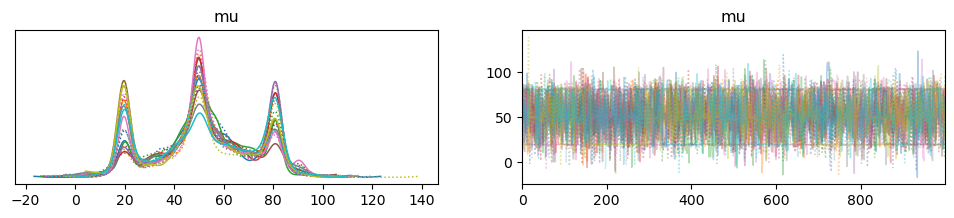

In [2]:
az.plot_trace(trace, var_names=["mu"])
plt.show()

As you most probably noticed, even the MCMC sampling for the one dimension of the data required around 15 minutes to finish (with 2 chains and only 1000 samples). If you tried to run the clustering on both dimensions (``use_2d = False``), you would see that it would take hours to run. So a compromise is to use another truncated approximation with Bayesian Gaussian Mixture (BGM).

Before looking at BGM, let's examine the traces. We see that for the average (centroid) of the clusters, the posterior includes 3 clear modes, pointing to 3 clusters. The trace plot shows a decent mixing as well, but one possibility is to use a longer burn in time.

Moving on to BGM, it assumes a maximum number of components and places a Dirichlet Process prior over the mixing weights using variational inference. This leads to significant speed ups. Also unnecessary components get *shrunk* (i.e., assigned very low weights), effectively removing them from the model.

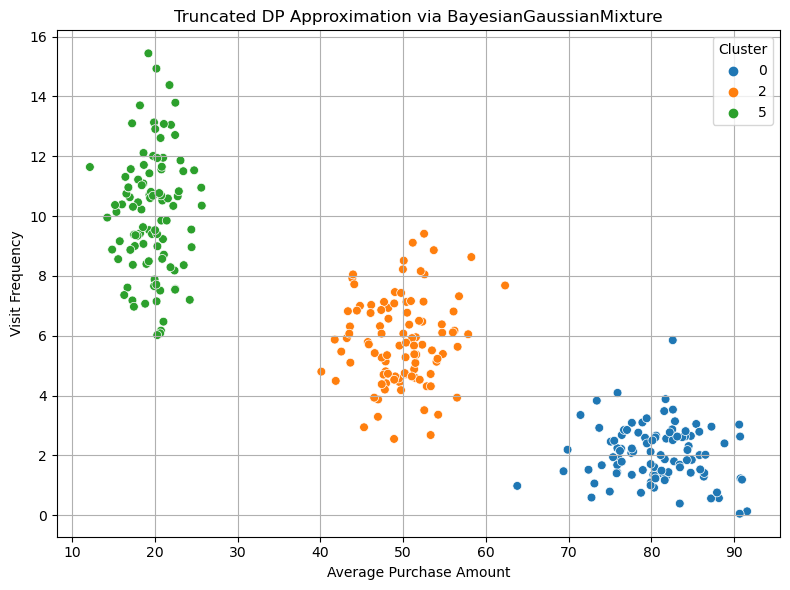

In [3]:
### TRUNCATED APPROXIMATION: BAYESIAN GAUSSIAN MIXTURE (Sklearn) ###

# This is a variational approximation to the DP mixture.
# n_components sets an upper bound; the model will drop unused components.

bgmm = BayesianGaussianMixture(
    n_components=10,  # Upper bound on number of clusters
    weight_concentration_prior_type='dirichlet_process',
    weight_concentration_prior=1e-2,  # Low alpha → fewer clusters
    covariance_type='full',
    max_iter=1000,
    random_state=42
)
bgmm.fit(X)
labels = bgmm.predict(X)

# Plot the clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette="tab10", s=40)
plt.title("Truncated DP Approximation via BayesianGaussianMixture")
plt.xlabel("Average Purchase Amount")
plt.ylabel("Visit Frequency")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

So overall, both approaches allow the number of clusters to adapt based on the data. However, ``PyMC`` gives us a full posterior uncertainty and flexible modeling, but it comes at a high computational tax. The BGM approach within ``sklearn`` provides an approximation much faster and it is easier to deploy. Also, as we have seen before, the VI approaches are less expressive. For example, while we can get cluster assigment probabilities -- if we ask for them; ``probs = bgmm.predict_proba(X)``), these are point estimates, while MCMC will provide us with the uncertainty of these cluster assignment probabilities as well.  